In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio
from glob import glob
import pathlib

## Completando informações dos poços

In [7]:
wells_info = pd.read_csv("well_coords.csv", index_col='id')
wells_info['Well'] = wells_info['Well'].apply(lambda x: x.upper())
wells_info.head()

,Well,x_coord,y_coord
id,,,
0,2-ANP-1-RJS,677,1722
1,3-BRSA-1064-RJS,652,1114
2,3-BRSA-1184-RJS,855,1230
3,3-BRSA-1195-RJS,1041,2322
4,7-BUZ-10-RJS,415,392


In [8]:
len(wells_info)

37

In [4]:
def get_las_files_from(dir_path:str) -> list:
    """
    Gets all .las files from dir_path. dir_path may be a regex or str.
    Returns a list with every file name found
    """
    full_filter = f"{str(dir_path)}*.las"
    return list(glob(full_filter))

In [5]:
target_dir_for_las_search = 'pocos_ANP/*/'
well_las_files = get_las_files_from(target_dir_for_las_search)

In [9]:
def get_well_file_name(file_path:str):
    return pathlib.Path(file_path).stem.upper().split('_')[0]

def filter_files_with_target_names(all_file_names:list, filter_files_names:list) -> list:
    """
    Filter all files with name in filter_files_names.
    Also, it first gets the uppercase stemmed file name and then splits it for '_'.

    Example: 
    stem(mY-file-Name_123.las).upper().split('_')[0] == MY-FILE-NAME
    
    """
    return list(filter(lambda x: get_well_file_name(x) in filter_files_names, all_file_names))

def filter_files_not_with_names(all_file_names:list, filter_files_names:list) -> list:
    return list(filter(lambda x: get_well_file_name(x) not in filter_files_names, all_file_names))

def read_well(well_file:str):
    return lasio.read(well_file)

def get_wells_y_limits_per_file(well_files:list) -> dict:
    wells_y_limits_dict = dict()
    for well_file in well_files:
        y_limits = tuple(read_well(well_file).df().index.values[[0,-1]].tolist())
        wells_y_limits_dict[get_well_file_name(well_file)] = y_limits
    return wells_y_limits_dict

def get_min_y_limit_for_file_name(file_path, limit_dict) -> tuple:
    return limit_dict[get_well_file_name(file_path)][0]

def get_max_y_limit_for_file_name(file_path, limit_dict) -> tuple:
    return limit_dict[get_well_file_name(file_path)][1]

def complete_wells_info_with_y_limits(wells_info:pd.DataFrame, wells_y_limits:dict) -> pd.DataFrame:
    wells_info_copy = wells_info
    wells_info_copy['min_y'] = wells_info['Well'].apply(
                                        lambda x: get_min_y_limit_for_file_name(x, wells_y_limits))
    wells_info_copy['max_y'] = wells_info['Well'].apply(
                                        lambda x: get_max_y_limit_for_file_name(x, wells_y_limits))
    
    return wells_info_copy

def complete_well_info_with_y_limits_from_las_files(wells_info:pd.DataFrame,
                                                    well_las_files:list) -> pd.DataFrame:
    wells_names = wells_info['Well'].to_list()
    matching_well_las_files = filter_files_with_target_names(well_las_files, wells_names)
    wells_y_limits_dict = get_wells_y_limits_per_file(matching_well_las_files)
    wells_info = complete_wells_info_with_y_limits(wells_info, wells_y_limits_dict)
    return wells_info

In [20]:
full_wells_info = complete_well_info_with_y_limits_from_las_files(wells_info, well_las_files)

In [10]:
full_wells_info.head()

,Unnamed: 0,id,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
0,0,0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176
1,1,1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186
2,2,2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180
3,3,3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180
4,4,4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156


In [22]:
full_wells_info.isna().sum()

Well       0
x_coord    0
y_coord    0
min_y      0
max_y      0
dtype: int64

In [23]:
filter_files_not_with_names(well_las_files, full_wells_info['Well'].to_list())

['pocos_ANP\\convertidas no projeto\\3-BRSA-1053-RJS.las']

Aparentemente, não temos os dados de coordenadas para esse poço acima.

In [24]:
# wells = [np.sort(lasio.read(x).df().index.values)[[0,-1]].tolist() for x in glob('pocos_ANP/*/*.las')]
# wells = np.array(sorted(wells))

In [56]:
def get_well_type_by_y_limits(well_row):
    max_y = well_row['max_y']
    min_y = well_row['min_y']
    if max_y - min_y >= 2000:
        return 'complete'

    if max_y < 4000:
        return 'top'
    
    return 'bottom'

In [57]:
full_wells_info['type'] = full_wells_info.apply(lambda x: get_well_type_by_y_limits(x), axis=1)

In [58]:
full_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y,type
id,,,,,,
0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom
1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom
2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom
3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom
4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom


In [20]:
bottom_wells = full_wells_info[full_wells_info['type'] == 'bottom']
top_wells = full_wells_info[full_wells_info['type'] == 'top']
complete_wells = full_wells_info[full_wells_info['type'] == 'complete']

In [21]:
full_wells_info['type'].value_counts()

type
bottom      17
complete    16
top          4
Name: count, dtype: int64

In [127]:
target_file = "wells_info_completed.csv"
full_wells_info.to_csv(target_file)

## Visualizando a distribuição dos poços por classe

In [91]:
def plot_full_y_range(x, ystart, ystop):
    color = 'r'
    timelines(x, ystart, ystop, 'range base', color=color)

def timelines(x, ystart, ystop, label, color='b'):
    """Plot timelines at x from ystart to ystop with given color."""
    plt.vlines(x, ystart, ystop, color, lw=4, zorder=3, label=label)
    plt.hlines(ystart, x+0.3, x-0.3, color, lw=2, zorder=3)
    plt.hlines(ystop, x+0.3, x-0.3, color, lw=2, zorder=3)

def plot_horizontal_line(min_x, max_x, y, label=True):
    if label:
        plt.plot([min_x, max_x], [y, y], color="grey", ls="--", zorder=0, label='Faixa alvo')
    else:
        plt.plot([min_x, max_x], [y, y], color="grey", ls="--", zorder=0)

def plot_wells_y_limits_by_class(wells_df:pd.DataFrame, color_dict:dict, target_col:str):
    unique_values_target_col = wells_df[target_col].unique()

    num_wells = len(wells_df)

    #This adds one up to the curr_x_range
    plot_full_y_range(0, 2000, 8000)

    if target_col == 'type':
        ordered_classes = ['complete', 'top', 'bottom']
    else:
        ordered_classes = list(unique_values_target_col)
        ordered_classes.sort()

    curr_x_range = None
    x_offset = 0
    for well_class in ordered_classes:
        target_wells = wells_df[wells_df[target_col] == well_class]
        if len(target_wells) > 0:
            ordered_wells = target_wells.sort_values(by='min_y', ascending=True)
            curr_x_range = np.arange(len(target_wells)) + x_offset + 1
            color = color_dict[well_class]
            timelines(curr_x_range, ordered_wells['min_y'], ordered_wells['max_y'], well_class, color)
            x_offset = curr_x_range.max()

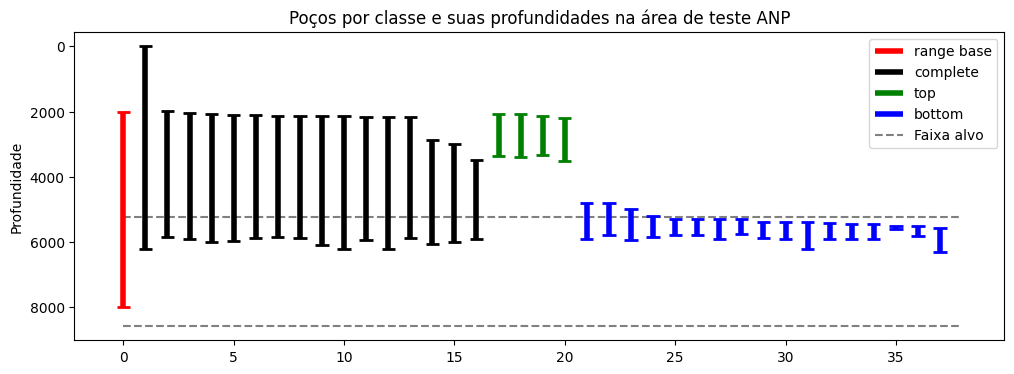

In [92]:
fig = plt.figure(figsize=(12,4))

wells_by_class_dict = {
    'complete': complete_wells,
    'top': top_wells,
    'bottom': bottom_wells
}

color_dict = {'complete': 'black', 'top':'green', 'bottom':'blue'}
num_wells = len(full_wells_info)

plot_wells_y_limits_by_class(full_wells_info, color_dict, target_col='type')
plot_horizontal_line(0, num_wells+1, 5246, label=True)
plot_horizontal_line(0, num_wells+1, 8583, label=False)

plt.gca().invert_yaxis()
plt.ylabel('Profundidade')
plt.title("Poços por classe e suas profundidades na área de teste ANP")
plt.legend()
plt.savefig("pocos_limites_z.png")
plt.show()

2000 e 8000 m, amostradas a cada 5 m

In [32]:
def plot_well_type(axs, well_type, wells_df, color, point_size=5):
    axs.scatter(wells_df['x_coord'], wells_df['y_coord'], s=point_size, 
            c=color)
    axs.set_title(well_type)

def plot_wells_coords_by_class_dict(wells_dict, color_dict, filename=None):
    # plt.figure(figsize=(6, 8))
    fig, axs = plt.subplots(2,2, sharex=True, sharey=True, figsize=(6, 8))

    fig.suptitle("Poços na área de teste da ANP")

    point_size = 8
    # Plot all wells
    for well_type, wells_df in wells_dict.items():
        axs[0, 0].scatter(wells_df['x_coord'], wells_df['y_coord'], s=point_size, 
            label=well_type, c=color_dict[well_type])
        axs[0, 0].set_title("Todos os poços")
    
    plot_well_type(axs[0, 1], 'complete', wells_dict['complete'], color_dict['complete'], point_size)
    plot_well_type(axs[1, 0], 'bottom', wells_dict['bottom'], color_dict['bottom'], point_size)
    plot_well_type(axs[1, 1], 'top', wells_dict['top'], color_dict['top'], point_size)

    y_lim = 2898
    x_lim = 1344
    for ax in axs.flat:
        ax.set(xlabel='x-coord', ylabel='y-coord')
        ax.set_xlim([0, x_lim])
        ax.set_ylim([0, y_lim])

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()

    # plt.title("Poços na área de teste ANP")
    # plt.xlabel("x")
    # plt.ylabel("y")
    # plt.ylim(0, 2898)
    # plt.xlim(0, 1344)
    plt.legend()
    if filename:
        plt.savefig(filename)
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


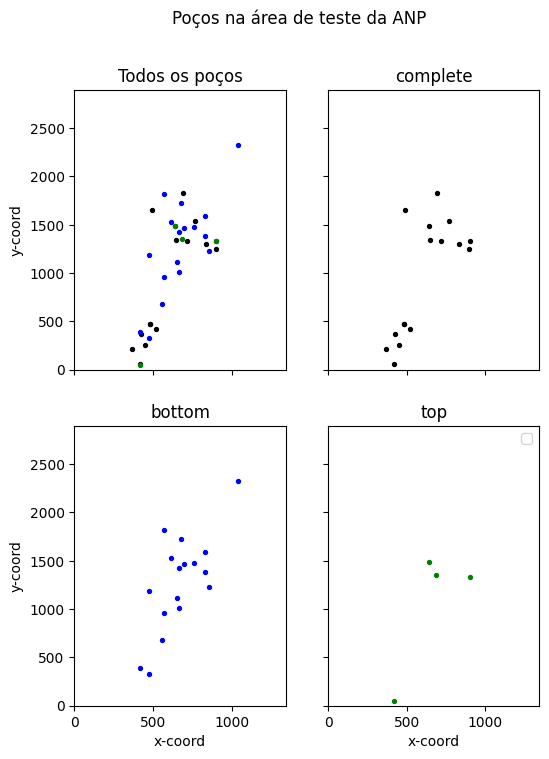

In [33]:
plot_wells_coords_by_class_dict(wells_by_class_dict, color_dict, filename='pocos_dist.png')

## Ajustando o range dos poços de acordo com a amostragem feita

O arquivo Franco_Florin.npy fornecido não possui range em z de 2000 a 8000 (6001 valores), mas sim, de 0 a 1200 (1201 valores). Isso mostra que a amostragem de porosidade foi realizada a cada 5 metros.

Dessa forma, vou criar colunas adicionais no wells_info_completed que indique os limites do range do poço de acordo com essa amostragem.

In [4]:
target_file = "wells_info_completed.csv"
full_wells_info = pd.read_csv(target_file)

In [5]:
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type
0,0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom
1,1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom
2,2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom
3,3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom
4,4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom


In [8]:
full_wells_info['min_y_adjusted'] = full_wells_info['min_y'] / 5
full_wells_info['max_y_adjusted'] = full_wells_info['max_y'] / 5


In [9]:
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
0,0,2-ANP-1-RJS,677,1722,5400.0,5880.0,bottom,1080.0,1176.0
1,1,3-BRSA-1064-RJS,652,1114,5000.0,5930.0,bottom,1000.0,1186.0
2,2,3-BRSA-1184-RJS,855,1230,5400.0,5900.0,bottom,1080.0,1180.0
3,3,3-BRSA-1195-RJS,1041,2322,5450.0,5900.0,bottom,1090.0,1180.0
4,4,7-BUZ-10-RJS,415,392,5300.0,5780.0,bottom,1060.0,1156.0


## Arredondando os valores das coordenadas

In [18]:
full_wells_info = full_wells_info.astype({'max_y':'int32', 'min_y':'int32', 
                        'min_y_adjusted':'int32', 'max_y_adjusted':'int32'})
full_wells_info.head()

,id,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
0,0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176
1,1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186
2,2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180
3,3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180
4,4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156


In [4]:
target_file = "wells_info_completed.csv"
full_wells_info.to_csv(target_file, index=False)

## Escolhendo áreas de poços para experimentos

In [161]:
target_file = "wells_info_completed.csv"
full_wells_info = pd.read_csv(target_file)

In [162]:
full_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176,NaN
1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186,NaN
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180,NaN
4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156,3.0


De acordo com a distribuição dos poços sugiro três áreas para experimentos:

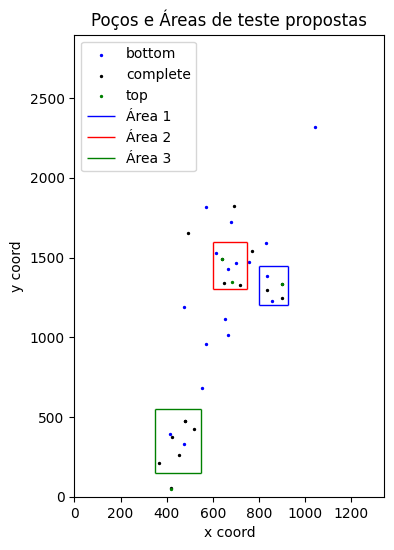

In [168]:
def plot_horizontal_line(min_x, max_x, y, label:str=None, color:str='grey', line_fmt:str='dashed'):
    if label:
        plt.hlines(y=y, xmin=min_x, xmax=max_x, color=color, linewidth=1, label=label)
    else:
        plt.hlines(y=y, xmin=min_x, xmax=max_x, color=color, linewidth=1)

def plot_vertical_line(min_y, max_y, x, label:str=None, color:str='grey'):
    if label:
        plt.vlines(x=x, ymin=min_y, ymax=max_y, color=color, linewidth=1, label=label)
    else:
        plt.vlines(x=x, ymin=min_y, ymax=max_y, color=color, linewidth=1)

def plot_area_limits(area_limits:dict, color:str, label:str):
    plot_horizontal_line(area_limits['min_x'], area_limits['max_x'], area_limits['min_y'], label=label, color=color)
    plot_horizontal_line(area_limits['min_x'], area_limits['max_x'], area_limits['max_y'], label=None, color=color)
    plot_vertical_line(area_limits['min_y'], area_limits['max_y'], area_limits['max_x'], label=None, color=color)
    plot_vertical_line(area_limits['min_y'], area_limits['max_y'], area_limits['min_x'], label=None, color=color)
     
def plot_wells_and_areas(wells_df:pd.DataFrame, areas_limits:list[dict], areas_colors:dict,
                         well_class_colors:dict, save_fig:bool=True):
    point_size = 2
    plt.figure(figsize=(4, 6))

    wells_types = wells_df['type'].unique()
    for well_type in wells_types:
            class_wells = wells_df[wells_df['type'] == well_type]
            plt.scatter(class_wells['x_coord'], class_wells['y_coord'], s=point_size, 
                label=well_type, c=well_class_colors[well_type])

    for area_idx, area_limits in enumerate(areas_limits):
        plot_area_limits(area_limits, areas_colors[area_idx+1],label=f'Área {area_idx+1}')

    y_lim = 2898
    x_lim = 1344
    plt.xlim((0, x_lim))
    plt.ylim((0, y_lim))
    plt.ylabel("y coord")
    plt.xlabel('x coord')
    plt.title("Poços e Áreas de teste propostas")
    plt.legend()
    if save_fig:
        plt.savefig("areas_de_teste_propostas.png")
    plt.show()
     
area_1_limits = {
    'max_x': 925,
    'min_x': 800,
    'min_y': 1200,
    'max_y': 1450
}

area_2_limits = {
    'max_x': 750,
    'min_x': 600,
    'min_y': 1300,
    'max_y': 1600
}

area_3_limits = {
    'max_x': 550,
    'min_x': 350,
    'min_y': 150,
    'max_y': 550
}

areas_limits = [area_1_limits, area_2_limits, area_3_limits]
areas_colors = {1:'blue', 2:'red', 3:'green'}
well_class_colors = {'complete': 'black', 'top':'green', 'bottom':'blue'}

plot_wells_and_areas(full_wells_info, areas_limits, areas_colors, well_class_colors, save_fig=True)


### Área 1

In [169]:
def select_wells_in_area(wells_df:pd.DataFrame, min_x:int, max_x:int, min_y:int, max_y:int) -> pd.DataFrame:
    return full_wells_info[full_wells_info['y_coord'].isin(range(min_y, max_y)) & full_wells_info['x_coord'].isin(range(min_x, max_x))]


In [170]:
area_1_wells = select_wells_in_area(full_wells_info, **area_1_limits)

In [171]:
area_1_wells

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
5,7-BUZ-12-RJS,834,1297,2118,5873,complete,423,1174,1.0
13,7-BUZ-30-RJS,833,1384,5300,5900,bottom,1060,1180,1.0
18,8-BUZ-21D-RJS,898,1246,2099,5978,complete,419,1195,1.0
24,8-BUZ-32D-RJS,901,1332,2079,3368,top,415,673,1.0
25,8-BUZ-32DA-RJS,901,1332,2858,6056,complete,571,1211,1.0


In [174]:
def plot_area_wells(wells_df:pd.DataFrame, area_num:int|str, save_img:bool=True):
    num_wells = len(wells_df)
    plot_wells_y_limits_by_class(wells_df, color_dict, target_col='type')
    plot_horizontal_line(0, num_wells+1, 5246, label='Faixa Alvo')
    plot_horizontal_line(0, num_wells+1, 8583)
    plt.gca().invert_yaxis()
    plt.ylabel('Profundidade')
    plt.title(f"Poços por classe e suas profundidades na área {area_num} de teste ANP")
    plt.legend()
    if save_img:
        plt.savefig(f"pocos_limites_z_area_{area_num}.png")
    plt.show()

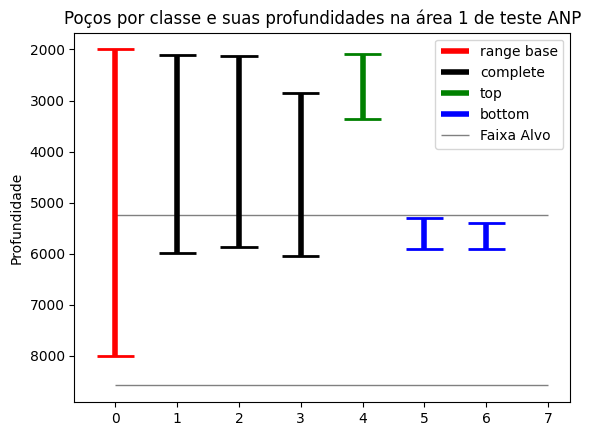

In [175]:
plot_area_wells(area_1_wells, 1, save_img=True)

### Área 2

In [106]:
area_2_wells = select_wells_in_area(full_wells_info, **area_2_limits)

In [107]:
area_2_wells

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
6,7-BUZ-13DA-RJS,685,1348,2086,3406,top,417,681
7,7-BUZ-14-RJS,642,1490,2134,3331,top,426,666
8,7-BUZ-14DA-RJS,640,1491,2129,5847,complete,425,1169
9,7-BUZ-17-RJS,699,1467,4800,5770,bottom,960,1154
14,7-BUZ-31D-RJS,648,1341,2170,5867,complete,434,1173
15,7-BUZ-6-RJS,612,1531,5460,5910,bottom,1092,1182
21,8-BUZ-27D-RJS,717,1329,2089,5999,complete,417,1199
29,9-BRSA-1191-RJS,665,1427,5280,5800,bottom,1056,1160


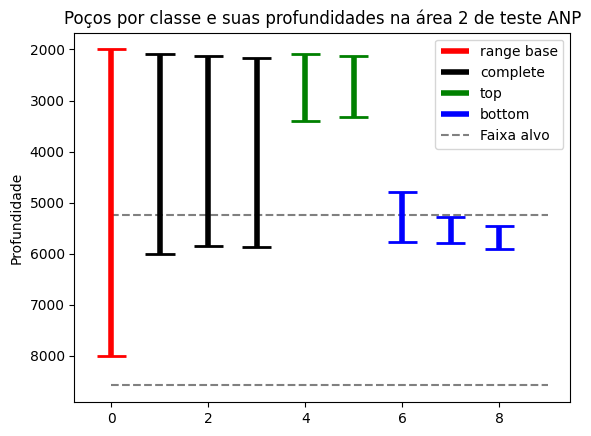

In [108]:
plot_area_wells(area_2_wells, 2, save_img=True)

### Área 3

In [111]:
area_3_wells = select_wells_in_area(full_wells_info, **area_3_limits)

In [112]:
area_3_wells

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted
4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156
10,7-BUZ-23-RJS,481,472,2137,5870,complete,427,1174
11,7-BUZ-25-RJS,481,472,1991,5837,complete,398,1167
12,7-BUZ-29D-RJS,425,372,2164,5929,complete,432,1185
17,8-BUZ-20-RJS,518,425,2141,6079,complete,428,1215
20,8-BUZ-26-RJS,452,260,2169,6203,complete,433,1240
32,9-BUZ-2-RJS,477,329,5570,6300,bottom,1114,1260
33,9-BUZ-3-RJS,367,214,0,6200,complete,0,1240


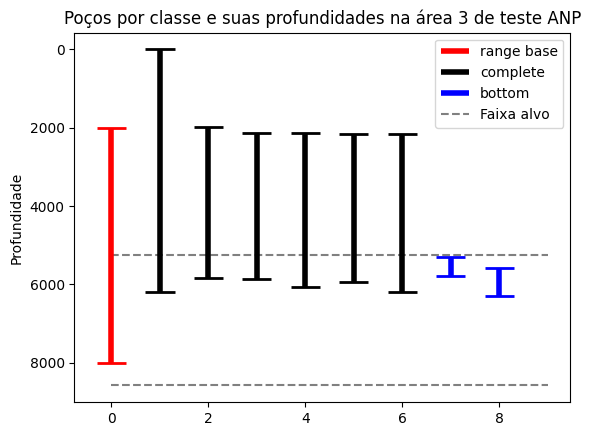

In [113]:
plot_area_wells(area_3_wells, 3, save_img=True)

### Adicionando informação sobre a área de teste dos poços

In [157]:
def well_is_in_area(well_x_coord:int, well_y_coord:int, 
                    area_max_x:int , area_min_x:int , area_max_y:int, area_min_y:int) -> bool:
    inside_x_range = well_x_coord >= area_min_x and well_x_coord <= area_max_x
    inside_y_range = well_y_coord >= area_min_y and well_y_coord <= area_max_y
    return inside_x_range and inside_y_range

def define_test_area(line, areas_limits):
    for area_idx, area_limit in enumerate(areas_limits):
        if well_is_in_area(line['x_coord'], line['y_coord'],
                           area_max_x=area_limit['max_x'], area_min_x=area_limit['min_x'],
                           area_max_y=area_limit['max_y'], area_min_y=area_limit['min_y']):
            return int(area_idx+1)
    
    return None
            
#define again for clarity
areas_limits = [area_1_limits, area_2_limits, area_3_limits]

full_wells_info['test_area'] = full_wells_info.apply(lambda line: define_test_area(line, areas_limits), axis=1)

In [160]:
target_file = "wells_info_completed.csv"
full_wells_info.to_csv(target_file, index=False)